# The Project
Simple image classification using transfer learning (ResNet50) on CIFAR-10.

## EDA

Train shape: (50000, 32, 32, 3) (50000, 1)
Test shape: (10000, 32, 32, 3) (10000, 1)


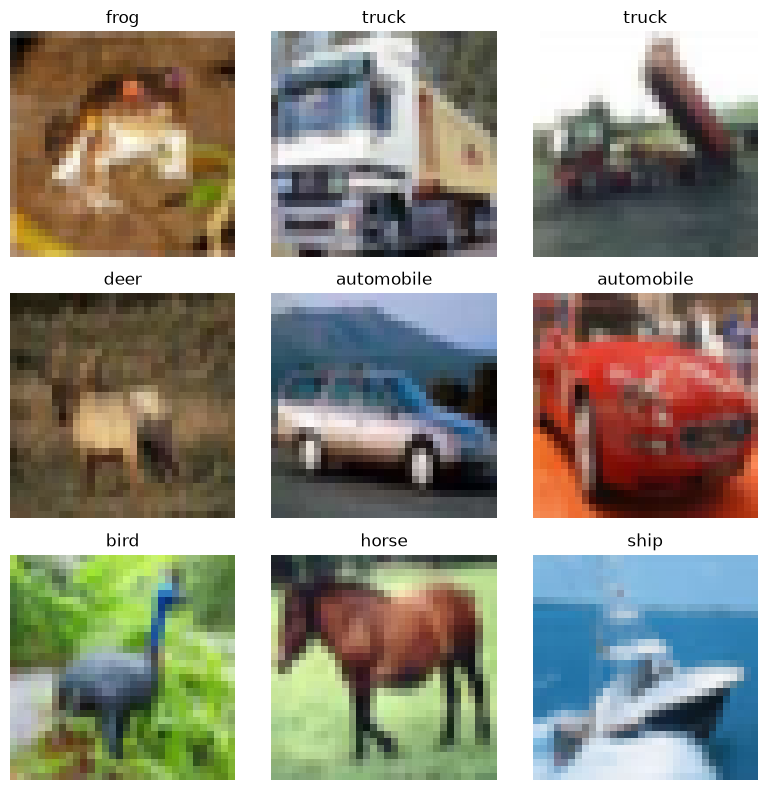

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar10

(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

print("Train shape:", x_train_full.shape, y_train_full.shape)
print("Test shape:", x_test.shape, y_test.shape)

class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train_full[i])
    plt.title(class_names[y_train_full[i][0]])
    plt.axis('off')
plt.tight_layout()
plt.show()

## Limiting the Dataset
Training data is limited to 10k images to save time (all 50k would give better performance). Testing data (10k) is kept as-is.

In [7]:
# Limit training data to 10k (Note: using all 50k would improve performance)
x_train = x_train_full[:10000]
y_train = y_train_full[:10000]

# Testing data stays at full 10k, no limiting needed
print("Training data used:", x_train.shape)
print("Testing data used:", x_test.shape)

Training data used: (10000, 32, 32, 3)
Testing data used: (10000, 32, 32, 3)


## Data Preprocessing

In [8]:
# Normalize pixel values from 0..255 to 0..1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

num_classes = len(class_names)

# One-hot encode labels
y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes)
y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes)

## Model Selection: Pretrained ResNet50 (Transfer Learning)

In [9]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

input_shape = (32, 32, 3)

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=input_shape
)

# Freeze the pretrained base
base_model.trainable = False

## Build the Top of the Network

In [10]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 1, 1, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,858,890 (91.01 MB)

 Trainable params: 271,178 (1.03 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Compile, Train, Evaluate

In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
history = model.fit(
    x_train, y_train_cat,
    epochs=5,
    validation_split=0.2
)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - accuracy: 0.1443 - loss: 2.2720 - val_accuracy: 0.2085 - val_loss: 2.1451
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - accuracy: 0.2139 - loss: 2.1296 - val_accuracy: 0.2205 - val_loss: 2.0659
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - accuracy: 0.2434 - loss: 2.0365 - val_accuracy: 0.2595 - val_loss: 1.9912
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - accuracy: 0.2581 - loss: 1.9967 - val_accuracy: 0.2555 - val_loss: 1.9948
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - accuracy: 0.2690 - loss: 1.9705 - val_accuracy: 0.2835 - val_loss: 1.9542


In [13]:
test_loss, test_accuracy = model.evaluate(x_test, y_test_cat)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.2900 - loss: 1.9340
Test loss: 1.9340
Test accuracy: 0.2900
